In [1]:
import nnfs
from nnfs.datasets import spiral_data
import numpy as np
import math
import matplotlib.pyplot as plt

nnfs.init()

### Categorical Cross-Entropy Loss

Our model spits out a probability distribution so our loss function needs to reflect that, hence the categorical cross-entropy function. It finds the difference, or loss, between the actual *‘y’* and predicted *‘y-hat’* distribution.

The typical form for categorical cross-entropy loss:

$L = -\sum_{i=1}^C y_i \log(p_i)$

where: \
    • C = number of classes (e.g., 3 if you have red, blue, green) \
    • yi​ = 1 if class i is the true class, 0 otherwise (from the one-hot target vector) \
    • pi(y-hat)​ = predicted probability for class i (after softmax).

If our softmax output is [0.7, 0.1, 0.2], the one-hot encoding for this would be [1, 0, 0]. We have 0.7 as the true class 1, and the other two outputs would be 0 for one-hot encoding. Lets plug some numbers into the formula: 

-(1*log(0.7) + 0 * log(0.1) + 0 * log (0.2)) =  −(−0.3567) = 0.3567

With all the craziness going on around the world right now it’s nice to know some things haven’t changed liked multiplying by 0 still equals 0, so we can simply the formula to:

L=−log(0.7) = 0.3567

The log used is the *natural log* or base *e*. Why it is used is another rabbit hole, for now, just shake your head in agreement that going forward the natural log is used. The higher a model’s confidence in its prediction the lower the loss, which makes sense since the loss is the difference between actual vs predicated values. If you’re 100% confident that any number * 0 = 0 your loss would be 0.0. Your confidence about having the next winning lotto ticket is rather low (as it should be) so that difference would be a very large number.

In [ ]:
#Example
print(math.log(1.0)) # 100% confident
print(math.log(0.5)) # 50% confident
print(math.log(0.000001)) # Extremely low confidence

0.0
-0.6931471805599453
-13.815510557964274


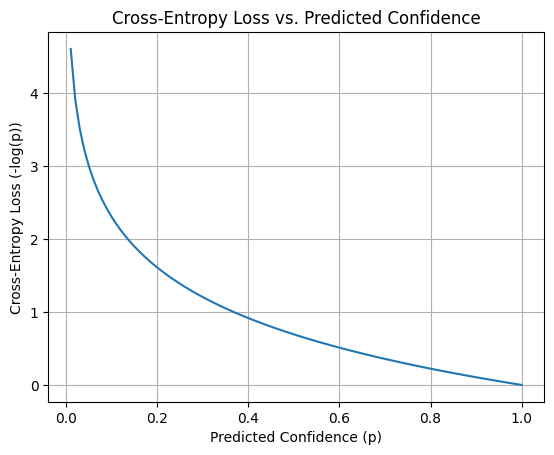

In [ ]:
p = np.linspace(0.01, 1.0, 100)
# Compute cross-entropy loss for a true positive class
loss = -np.log(p)

plt.figure()
plt.plot(p, loss)
plt.xlabel('Predicted Confidence (p)')
plt.ylabel('Cross-Entropy Loss (-log(p))')
plt.title('Cross-Entropy Loss vs. Predicted Confidence')
plt.grid(True)
plt.show()

This curvature should probably be a bit more extreme with a more 'hockey-stick' look to the curvature but hey I'm trying. The plot above shows how the cross-entropy loss 𝐿(𝑝) = −ln(𝑝) behaves as the model’s predicted confidence 𝑝 (for the true class) varies from 0 to 1: 
- As 𝑝→1: the loss drops toward 0, meaning high confidence in the correct class yields almost no penalty.
- As 𝑝→0: the loss shoots toward +∞, heavily penalizing predictions that assign near-zero probability to the true class.
- Rapid decrease: most of the loss change happens for 𝑝 in the low range (0–0.5). Gaining a little confidence from very low 𝑝 yields a large reduction in loss.

**This** curvature is what drives gradient updates.

Recall that this is only the first pass through the network with randomly initialized weights, so this first calculation could be off by a wide margin. You compute the softmax and get something like [0.7,0.1,0.2], then compute the loss and back‑propagate to update the weights. On the next forward pass, with those updated weights, you’ll get a new output distribution—maybe [0.2,0.1,0.7] or something else entirely. Over many such passes (epochs), gradient descent nudges the weights so that eventually the network’s outputs align more closely with the true one‑hot targets. But we’re not getting into back-propagation just yet.

Since I mentioned multiplying by 0; dividing by 0, or in our case *log(0)* also needs to be talked about. Regardless it is still undefined, despite what some elementary school teacher and principal said (yes, a teacher claimed dividing by 0 = 0). The model could output 0, so we need to deal with that contingency. log(p) and if p = 0, you get -∞. Also we don’t want 1 as an output either, so we’ll clip both ends to make the numbers close but not equal to 0 and 1.

In [4]:
y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

NameError: name 'y_pred' is not defined

#### Previous code

In [2]:
#Spiral data, shape(300, 2)
X, y = spiral_data(samples=100, classes=3)

# Define Layer_Dense class
class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)  # Small random weights
        self.biases = np.zeros((1, n_neurons))  # Initialize biases to zero

    # Forward pass
    def forward(self, inputs):
        # Calculate output values from inputs, weights, and biases
        self.output = np.dot(inputs, self.weights) + self.biases
        
class Activation_ReLU:
    def forward(self, inputs):
        #Calculates output values from inputs of dense layer
        self.output = np.maximum(0, inputs)

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) #Unnormalized probabilities
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        
        self.output = probabilities



### New Loss code

In [3]:
#Common Loss Class
class Loss:
    #Calculates data and regularization losses
    #given model output and ground truth values
    def calculate(self, output, y):
        #Calculate sample losses
        sample_losses = self.forward(output, y)
        
        #Caculate average loss  into a single scalar
        data_loss = np.mean(sample_losses)
        
        return data_loss
    
#Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
    #Forward pass
    def forward(self, y_pred, y_true):
        #number of samples in a batch
        samples = len(y_pred) # how many examples are in the batch.
        
        #Clip data to prevent dividing by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        #Probabilities for target values. Picks the probability assigned to the true class
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
            
        #Mask values - only for one-hot encoded lables. Multiplies the clipped probabilities by the one-hot vector (zeros everywhere except at the true class), then sums across classes to pick out the true-class probability.
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped*y_true,
                axis=1
            )
        
        #Losses. For each sample, take the log of its true-class probability, flip the sign, and that’s your loss. Low probability = high loss; high probability = low loss.
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

In [ ]:
# Define neural network layer with 2 inputs (for 2D data) and 3 output neurons, shape(2, 3)
dense1 = Layer_Dense(2, 3)

#ReLU Activation
activation1 = Activation_ReLU()

#Second dense layer takes output of previous layer and outputs 3 values
dense2 = Layer_Dense(3,3)

#Create Softmax activation
activation2 = Activation_Softmax()

#New Loss code added
loss_function = Loss_CategoricalCrossentropy()

# Perform forward pass with the spiral data
dense1.forward(X)

#Output of first layer to input of first activation function ReLU
activation1.forward(dense1.output)

#Takes output of activation function for forward pass through second dense layer.
dense2.forward(activation1.output)

#Takes output of second dense layer
activation2.forward(dense2.output)

#Output sample
print(activation2.output[:5])

#New loss coded added
#Performs forward pass through activation function; takes output of second dense layer
#and returns loss
loss = loss_function.calculate(activation2.output, y)

print('loss:', loss)

[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]
loss: 1.0986104
acc: 0.34


#### Accuracy Calculation

"Describes how often the largest confidence is the correct class. Uses the *argmax* values from teh *softmax outputs* and compares them to the targets."

In [7]:
#Calculate accuracy from output of activatgion2 and targets calculate values along first axis
predictions = np.argmax(activation2.output, axis=1)
if len(y.shape) == 2:
    y = np.argmax(y, axis=1)
accuracy = np.mean(predictions == y)

print('acc:', accuracy)

acc: 0.34


And all that gives us...the same output as before!? Yes, it isn't really doing anything new but it is setting us up for success later on, since we now have a loss number that we can use to adjust the weights and biases to decrease the loss.